In [1]:
# This script trains the DeepHit model on the provided dataset and 
# evaluates its performance using the C-index at a specified time horizon.
# It also includes a permutation feature importance analysis to identify
# which features are most influential for the model's predictions at that horizon.
import os
import random
import numpy as np
import tensorflow as tf
from trainDeepHit import *
from sklearn.model_selection import KFold
from utils_eval import c_index
import pandas as pd
import ImportDatabase as impt
from ClassDeepHit import DeepHitPlus
from sklearn.model_selection import train_test_split
from dotenv import load_dotenv
from pathlib import Path
from lifelines import AalenJohansenFitter
import matplotlib.pyplot as plt
from model_evaluation import *

load_dotenv()

/Users/mehman/Projects/DeepHit_updated/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [23]:
SEED = 321

num_Event = 2
eval_time = [12]
CV_ITERATION = 5
eval_horizon = 12  # same as eval_time, used for C-index evaluation

def setSeed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["TF_DETERMINISTIC_OPS"] = "1"   # deterministic TF ops
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

setSeed(SEED)

In [27]:
plot_feature_names = [
    "Age",
    "Tumour laterality",
    "T category",
    "N category",
    "Cancer stage",
    "M category",
    "Previous CVD",
    "Planned Chemotherapy",
    "Planned Anti-HER2 therapy",
    "Planned Endocrine therapy",
    "Planned Radiotherapy",
    "ATC A02",
    "ATC A03",
    "ATC A04",
    "ATC A05",
    "ATC A06",
    "ATC A07",
    "ATC A08",
    "ATC A09",
    "ATC A10",
    "ATC A11",
    "ATC A12",
    "ATC B01",
    "ATC B02",
    "ATC B03",
    "ATC B05",
    "ATC C01",
    "ATC C02",
    "ATC C03",
    "ATC C05",
    "ATC C07",
    "ATC C08",
    "ATC C09",
    "ATC C10",
    "ATC G03",
    "ATC G04",
    "ATC H01",
    "ATC H02",
    "ATC H03",
    "ATC H04",
    "ATC H05",
    "ATC J01",
    "ATC J02",
    "ATC J04",
    "ATC J05",
    "ATC L01",
    "ATC L02",
    "ATC L03",
    "ATC L04",
    "ATC M01",
    "ATC M05",
    "ATC N02",
    "ATC N03",
    "ATC N04",
    "ATC N05",
    "ATC N06",
    "ATC N07",
    "ATC R03",
    "ATC R06",
    "Hypertension",
    "Diabetes",
    "Hyperlipidemia",
    "Obesity",
    "Kidney disease",
    "ICD-10 A00–B99",
    "ICD-10 C00–D48",
    "ICD-10 D50–D89",
    "ICD-10 E00–E90",
    "ICD-10 F00–F99",
    "ICD-10 G00–G99",
    "ICD-10 H00–H59",
    "ICD-10 I00–I99",
    "ICD-10 J00–J99",
    "ICD-10 K00–K93",
    "ICD-10 L00–L99",
    "ICD-10 M00–M99",
    "ICD-10 N00–N99",
    "ICD-10 R00–R99",
    "ICD-10 S00–T98",
    "ICD-10 Z00–Z99",
    "DVC",
    "EH",
    "TIA",
    "SCR",
    "PER",
    "Number of visits",
    "First CVD diagnosis score",
    "Maximum hospital stay",
]

In [3]:
# ==================================================
# Load data
# ==================================================
data_dir = Path(os.getenv("DATA_DIR"))
path = data_dir / "Region_Sthlm_Gotland_model_data_binary.csv"

x_dim, (data, time, label), (mask1, mask2), feature_names = impt.import_dataset(path,time_scale=1.2)
data_df = pd.DataFrame(data, columns=feature_names)
reference_patient = data_df.mode().iloc[0]

# Normalize age and log-transform certain features
age_mean = data[:, 0].mean()
age_std = data[:, 0].std()

data[:, 0] = (data[:, 0] - age_mean) / age_std
reference_patient["Age"] = (reference_patient["Age"] - age_mean) / age_std

for j in range(data.shape[1] - 3, data.shape[1]): 
    data[:, j] = np.log1p(data[:, j])
    data[:, j] = (data[:, j] - data[:, j].mean()) / data[:, j].std()
    reference_patient[feature_names[j]] = (np.log1p(reference_patient[feature_names[j]]) - data[:, j].mean()) / data[:, j].std()


In [4]:
# ==================================================
# Train / Validation split
# ==================================================
param_grid = {
    "shared_layers": [
        (32, 16),
        (32, 16, 8),
        (64, 32),
        (64, 4),
        (16, 8, 4),
        (16, 8)
    ],
    "MR_layers": [
        (4, 4),
        (4, 8),
        (8, 8),
    ],
    "CR_layers": [
        (4, 4),
        (4, 8),
        (8, 8),
    ],
    "dropout": [0.1, 0.25, 0.4]
}
results_df = optimize_hyperparameters_grid_search(data, time, label, mask1, mask2, param_grid, CV_ITERATION=5, eval_time=[12])






===== START TRAINING =====



KeyboardInterrupt: 

In [4]:
# Final traing of the model after cross-validation, with the best hyperparameters, on the entire dataset
'''model = DeepHitPlus(
    num_event=num_Event,
    num_bins=num_bins,
    shared_layers=(30, 15, 5),
    MR_layers=[5, 10],
    CR_layers=(5, 10),
    dropout=0.25   
)'''
num_bins = mask2.shape[1]   # T (time bins)
model = DeepHitPlus(
    num_event=num_Event,
    num_bins=num_bins,
    shared_layers=(32, 16),
    MR_layers=[10, 10],
    CR_layers=(5, 10),
    dropout=0.1   
)

model = TrainDeepHit(model, data, mask1, mask2, time, label,
                eval_time = [12], 
                test_size = 0.2, max_epochs = 100, batch_size = 128, learning_rate = 1e-3, alpha=1.0, beta=1.0)



===== START TRAINING =====

Epoch 000 | Train 4.4589 (LL 2.2418, Rank 2.2171) | Test 45.3040 | Test C-index 0.7827 (competing event: 0.7576)
Epoch 001 | Train 2.4392 (LL 0.6296, Rank 1.8096) | Test 42.4220 | Test C-index 0.8392 (competing event: 0.8558)
Epoch 002 | Train 2.0098 (LL 0.4270, Rank 1.5828) | Test 38.7010 | Test C-index 0.8386 (competing event: 0.8563)
Epoch 003 | Train 1.7914 (LL 0.3345, Rank 1.4570) | Test 36.7080 | Test C-index 0.8325 (competing event: 0.8663)
Epoch 004 | Train 1.7112 (LL 0.3341, Rank 1.3771) | Test 36.1375 | Test C-index 0.8329 (competing event: 0.8607)
Epoch 005 | Train 1.6546 (LL 0.3229, Rank 1.3317) | Test 35.6525 | Test C-index 0.8378 (competing event: 0.8687)
Epoch 006 | Train 1.5899 (LL 0.3274, Rank 1.2624) | Test 34.6619 | Test C-index 0.8371 (competing event: 0.8694)
Epoch 007 | Train 1.5458 (LL 0.3145, Rank 1.2314) | Test 34.3796 | Test C-index 0.8379 (competing event: 0.8655)
Epoch 008 | Train 1.5081 (LL 0.3260, Rank 1.1821) | Test 34.7032 | 

In [5]:
pfi = permutation_feature_importance(
    model=model,
    x_val=va_data,
    time_val=va_time,
    label_val=va_label,
    eval_horizon=eval_horizon,
    n_repeats=50
)

print("PFI shape:", pfi.shape)  # (num_Event, num_features)


# Top 10 features per event
for k in range(num_Event):
    top_idx = np.argsort(-pfi[k])[:10]

    print(f"\nTop features for event {k+1}:")

    for i in top_idx:
        print(f"{feature_names[i]}: {pfi[k, i]:.3f}")



NameError: name 'va_data' is not defined

In [5]:
path = np.array([
    data_dir / "Region_Uppsala_Örebro_model_data_binary.csv",
    data_dir / "Region_Väst_model_data_binary.csv",
    data_dir / "Region_Syd_model_data_binary.csv",
    data_dir / "Region_Sydöstra_model_data_binary.csv",
    data_dir / "Region_Norr_model_data_binary.csv"]
    )
Region_names = {
    0: "Region Uppsala_Örebro",
    1: "Region Väst",
    2: "Region Syd",
    3: "Region Sydöstra",
    4: "Region Norr"
}

for i in range(len(path)):

    x_dim, (data, time, label), (mask1, mask2), feature_names = impt.import_dataset(path[i],time_scale=1.2)

    num_Category = mask2.shape[1]   # T (time bins)
    eval_time = [12]
    data[:, 0] = (data[:, 0] - data[:, 0].mean()) / data[:, 0].std()

    for j in range(data.shape[1] - 3, data.shape[1]):
        data[:, j] = np.log1p(data[:, j])
        data[:, j] = (data[:, j] - data[:, j].mean()) / data[:, j].std()

    data   = data.astype(np.float32)
    mask1  = mask1.astype(np.float32)
    mask2  = mask2.astype(np.float32)
    time   = time.astype(np.float32)
    label  = label.astype(np.int32) 

    baseline, ci_lower, ci_upper, bootstrap_scores = bootstrap_cindex_at_time(
    model,
    data,
    time,
    label,
    eval_horizon,
    n_bootstrap=3,
    seed=42
)

    print(f"{Region_names[i]:<25}\t"
          f"main risk: {baseline[0]:.3f} (95% CI: {ci_lower[0]:.3f} - {ci_upper[0]:.3f})\t"
          f"competing risk: {baseline[1]:.3f} (95% CI: {ci_lower[1]:.3f} - {ci_upper[1]:.3f})")


TypeError: compute_cindex_at_time() missing 1 required positional argument: 'eval_horizon'

/Users/mehman/Projects/DeepHit_updated/venv/lib/python3.13/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
/Users/mehman/Projects/DeepHit_updated/venv/lib/python3.13/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
/Users/mehman/Projects/DeepHit_updated/venv/lib/python3.13/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(


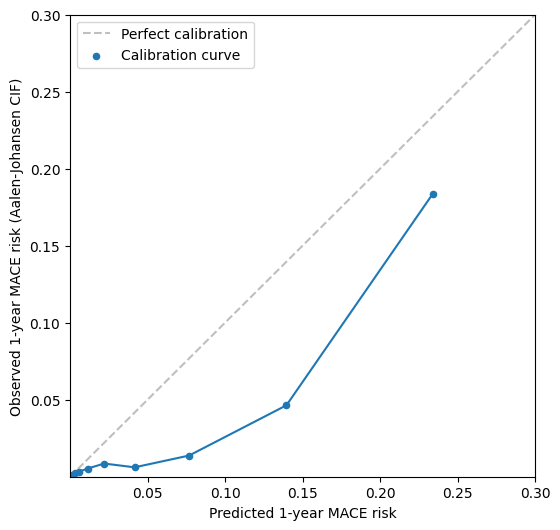

Optimization terminated successfully.
         Current function value: 0.088887
         Iterations 10
--------------------------------
Calibration intercept: -0.08745946124461515
Calibration slope: 1.4123431526849466
--------------------------------


In [5]:
# ==================================================
# Load data
# ==================================================
data_dir = Path(os.getenv("DATA_DIR"))
path = data_dir / "Region_sthlm_Gotland_model_data_binary.csv"

x_dim, (data, time, label), (mask1, mask2), feature_names = impt.import_dataset(path,time_scale=1.2)

# Normalize age and log-transform certain features
data[:, 0] = (data[:, 0] - data[:, 0].mean()) / data[:, 0].std()

for j in range(data.shape[1] - 3, data.shape[1]): 
    data[:, j] = np.log1p(data[:, j])
    data[:, j] = (data[:, j] - data[:, j].mean()) / data[:, j].std()

# --------------------------------------------------
# Ensure TensorFlow-compatible dtypes
# --------------------------------------------------
data   = data.astype(np.float32)
mask1  = mask1.astype(np.float32)
mask2  = mask2.astype(np.float32)
time   = time.astype(np.float32)
label  = label.astype(np.int32)   

# ==================================================
# 1. Predict from DeepHit model
# ==================================================
calibration_results = deep_hit_calibration(
    model=model,
    data=data,
    time=time,
    label=label,
    eval_time=eval_time,
    risk_index=0,
    plot_curve=True
)


--------------------------------
Brier score at 12 months: 0.024237754848198127
Integrated Brier Score: 0.01605258175980678
--------------------------------


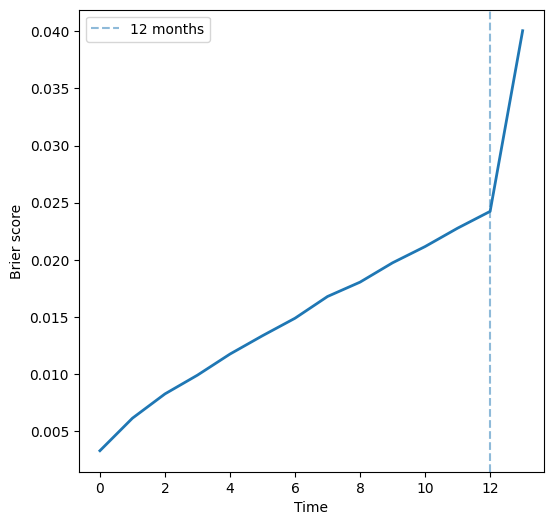

In [7]:
brier_results = evaluate_brier_score(
    model=model,
    data=data,
    time=time,
    label=label,
    eval_time=12,
    mace_index=0
)


Decision-curve analysis results:
 threshold  Predictive_model  Treat_all  Treat_none
     0.000          0.025924   0.025924         0.0
     0.005          0.022220   0.021029         0.0
     0.010          0.019513   0.016085         0.0
     0.030          0.012308  -0.004202         0.0
     0.050          0.007995  -0.025343         0.0
     0.075          0.004192  -0.053055         0.0
     0.100          0.001974  -0.082306         0.0


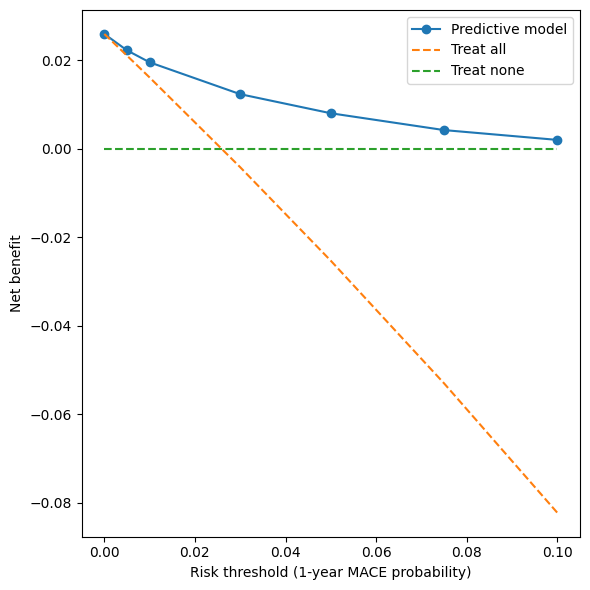

In [8]:
dca_results = deep_hit_decision_curve(
    model=model,
    data=data,
    time=time,
    label=label,
    eval_time=eval_time
)

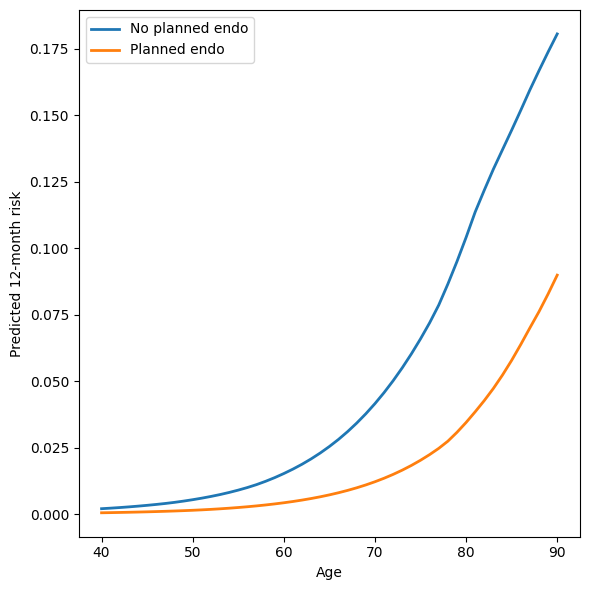

In [ ]:
data_dir = Path(os.getenv("DATA_DIR"))
path = data_dir / "Region_Sthlm_Gotland_model_data_binary.csv"

x_dim, (data, time, label), (mask1, mask2), feature_names = impt.import_dataset(path,time_scale=1.2)
data_df = pd.DataFrame(data, columns=feature_names)
reference_patient = data_df.mode().iloc[0]

# Normalize age and log-transform certain features
age_mean = data[:, 0].mean()
age_std = data[:, 0].std()

data[:, 0] = (data[:, 0] - age_mean) / age_std
reference_patient["Age"] = (reference_patient["Age"] - age_mean) / age_std

for j in range(data.shape[1] - 3, data.shape[1]): 
    data[:, j] = np.log1p(data[:, j])
    data[:, j] = (data[:, j] - data[:, j].mean()) / data[:, j].std()
    reference_patient[feature_names[j]] = (np.log1p(reference_patient[feature_names[j]]) - data[:, j].mean()) / data[:, j].std()

risk_comparison = plot_feature_risk_comparison(
    model=model,
    reference_patient=reference_patient,
    varying_feature="Age",
    varying_values=np.arange(40, 91),
    comparison_feature=feature_names[9],  
    comparison_values=[0, 1],
    feature_mean=age_mean,
    feature_std=age_std,
    comparison_labels=[
        "No planned " + feature_names[9],
        "Planned " + feature_names[9],
    ],
    event_index=0,
    eval_time=12,
)


In [25]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import shap

from matplotlib.ticker import AutoMinorLocator


# ============================================================
# 1. Calculate time-dependent SHAP
# ============================================================

shap_results = compute_time_dependent_shap(
    model=model,
    data=data,
    feature_names=plot_feature_names,
    event_index=0,
    horizon=12,
    n_background=50,
    seed=321,
)



PermutationExplainer explainer: 15932it [04:49, 53.30it/s]                           


Mean reconstruction error: 9.799045246548974e-11
Maximum reconstruction error: 7.978329941149553e-10
   Feature_index                    Feature  Mean_integrated_absolute_SHAP
0              0                        Age                       0.269534
1             87      Maximum hospital stay                       0.099501
2              7               Chemotherapy                       0.095585
3              9          Endocrine therapy                       0.076572
4             32                    ATC C09                       0.069728
5             86  First CVD diagnosis score                       0.067734
6             28                    ATC C03                       0.067400
7             85           Number of visits                       0.055457
8             34                    ATC G03                       0.042857
9             26                    ATC C01                       0.038415


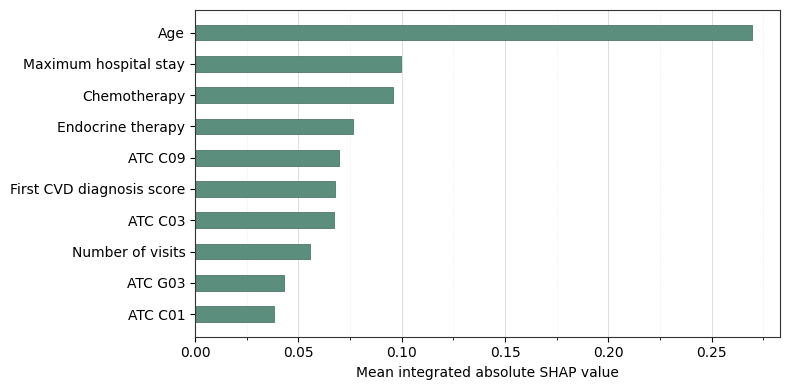

In [26]:

# ============================================================
# 2. Extract outputs
# ============================================================

importance_table = shap_results[
    "importance_table"
]

global_importance = shap_results[
    "global_importance"
]

mean_absolute_shap_by_time = shap_results[
    "mean_absolute_shap_by_time"
]

shap_at_horizon = shap_results[
    "shap_at_horizon"
]

explain_data = shap_results[
    "explain_data"
]

time_points = shap_results[
    "time_points"
]

feature_names = shap_results[
    "feature_names"
]

horizon = shap_results[
    "horizon"
]

reconstruction_error = shap_results[
    "reconstruction_error"
]


# ============================================================
# 3. Settings
# ============================================================

top_features = 10
show_plots = True

output_dir = Path("shap")
output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    "Mean reconstruction error:",
    reconstruction_error.mean(),
)

print(
    "Maximum reconstruction error:",
    reconstruction_error.max(),
)

print(
    importance_table.head(top_features)
)

importance_table.to_csv(
    output_dir
    / "DeepHit_time_dependent_SHAP_importance.csv",
    index=False,
)


def finish_plot(
    fig,
    filename,
):
    fig.tight_layout()

    fig.savefig(
        output_dir / filename,
        dpi=600,
        bbox_inches="tight",
    )

    if show_plots:
        plt.show()
    else:
        plt.close(fig)


# ============================================================
# 4. Global integrated-importance plot
# ============================================================

global_plot_data = (
    importance_table
    .head(top_features)
    .sort_values(
        "Mean_integrated_absolute_SHAP",
        ascending=True,
    )
)

fig, ax = plt.subplots(
    figsize=(8, 4)
)

ax.barh(
    global_plot_data["Feature"],
    global_plot_data[
        "Mean_integrated_absolute_SHAP"
    ],
    height=0.5,
    color="#5B8E7D",
    edgecolor="#3F6659",
    linewidth=0.5,
)

ax.set_xlabel(
    "Mean integrated absolute SHAP value"
)

ax.set_axisbelow(True)

ax.grid(
    axis="x",
    which="major",
    color="#C8C8C8",
    linestyle="-",
    linewidth=0.6,
    alpha=0.7,
)

ax.xaxis.set_minor_locator(
    AutoMinorLocator(2)
)

ax.grid(
    axis="x",
    which="minor",
    color="#E0E0E0",
    linestyle=":",
    linewidth=0.5,
    alpha=0.8,
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("#333333")
    spine.set_linewidth(0.8)

finish_plot(
    fig,
    "DeepHit_global_time_dependent_SHAP.png",
)


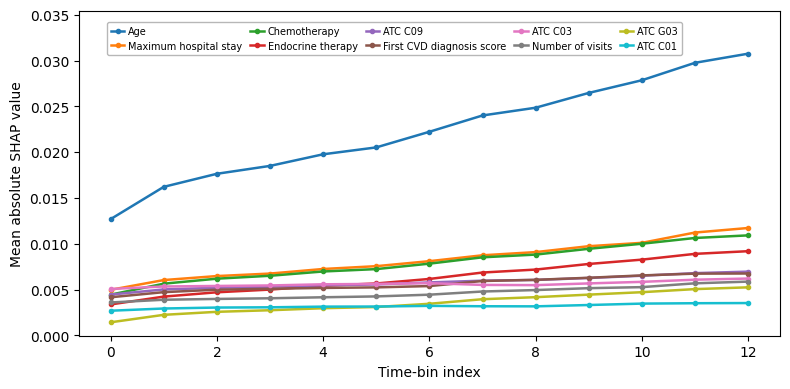

In [31]:
# ============================================================
# 5. Population-level importance over time
# ============================================================

global_top_indices = np.argsort(
    -global_importance
)[:top_features]

fig, ax = plt.subplots(
    figsize=(8, 4)
)

for feature_index in global_top_indices:
    ax.plot(
        time_points,
        mean_absolute_shap_by_time[
            feature_index,
            :
        ],
        marker="o",
        markersize=3,
        linewidth=1.8,
        label=feature_names[feature_index],
    )

ax.set_xlabel("Time-bin index")
ax.set_ylabel("Mean absolute SHAP value")

# Add space for the internal legend
y_min, y_max = ax.get_ylim()

ax.set_ylim(
    y_min,
    y_max + 0.1 * (y_max - y_min),
)

# Create exactly two legend rows
legend_columns = int(
    np.ceil(
        len(global_top_indices) / 2
    )
)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.45, 0.98),
    ncol=legend_columns,
    fontsize=7,
    frameon=True,
    framealpha=0.9,
    facecolor="white",
    edgecolor="#B0B0B0",
    columnspacing=0.8,
    handlelength=1.4,
    handletextpad=0.4,
)

finish_plot(
    fig,
    "DeepHit_population_time_dependent_SHAP.png",
)


/var/folders/vj/tlj0y71x381bb5cfc_8ylv2nf7_f43/T/ipykernel_21325/2495803822.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


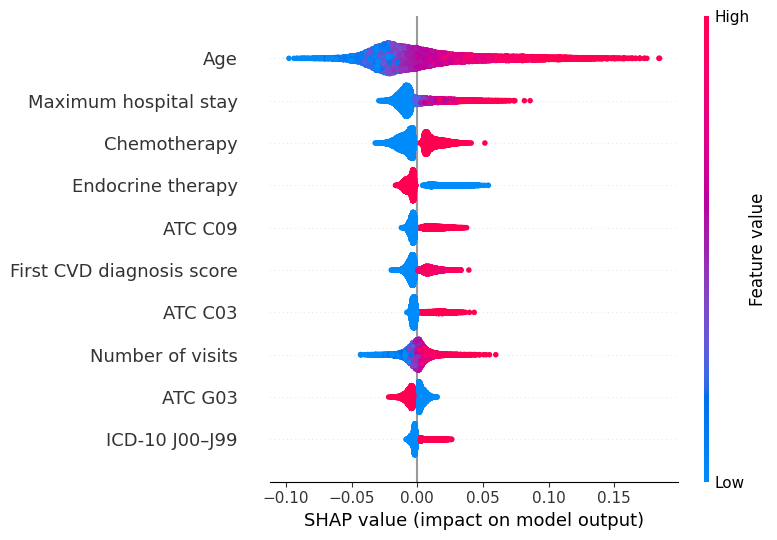

In [32]:
# ============================================================
# 6. SHAP summary at selected horizon
# ============================================================

shap.summary_plot(
    shap_at_horizon,
    explain_data,
    feature_names=feature_names,
    max_display=top_features,
    show=False,
)

fig = plt.gcf()

finish_plot(
    fig,
    f"DeepHit_SHAP_summary_at_horizon_{horizon}.png",
)

In [22]:
feature_names

['Age',
 'Side',
 'Tclass',
 'Nclass',
 'Stage',
 'Mclass',
 'CVDbefore',
 'chemo',
 'antiHer2',
 'endo',
 'RT',
 'ATC_L2_A02',
 'ATC_L2_A03',
 'ATC_L2_A04',
 'ATC_L2_A05',
 'ATC_L2_A06',
 'ATC_L2_A07',
 'ATC_L2_A08',
 'ATC_L2_A09',
 'ATC_L2_A10',
 'ATC_L2_A11',
 'ATC_L2_A12',
 'ATC_L2_B01',
 'ATC_L2_B02',
 'ATC_L2_B03',
 'ATC_L2_B05',
 'ATC_L2_C01',
 'ATC_L2_C02',
 'ATC_L2_C03',
 'ATC_L2_C05',
 'ATC_L2_C07',
 'ATC_L2_C08',
 'ATC_L2_C09',
 'ATC_L2_C10',
 'ATC_L2_G03',
 'ATC_L2_G04',
 'ATC_L2_H01',
 'ATC_L2_H02',
 'ATC_L2_H03',
 'ATC_L2_H04',
 'ATC_L2_H05',
 'ATC_L2_J01',
 'ATC_L2_J02',
 'ATC_L2_J04',
 'ATC_L2_J05',
 'ATC_L2_L01',
 'ATC_L2_L02',
 'ATC_L2_L03',
 'ATC_L2_L04',
 'ATC_L2_M01',
 'ATC_L2_M05',
 'ATC_L2_N02',
 'ATC_L2_N03',
 'ATC_L2_N04',
 'ATC_L2_N05',
 'ATC_L2_N06',
 'ATC_L2_N07',
 'ATC_L2_R03',
 'ATC_L2_R06',
 'HT',
 'Diabetes',
 'Hyperlipidemia',
 'Obesity',
 'KDRF',
 'A00_B99',
 'C00_D48',
 'D50_D89',
 'E00_E90',
 'F00_F99',
 'G00_G99',
 'H00_H59',
 'I00_I99',
 'J00_J99',